In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import torch

# 设置中文字体（可选）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

print("所有库导入成功！")

所有库导入成功！


第2.1题：线性代数计算
已知：
向量 a = [2, -1, 3]ᵀ，b = [1, 4, -2]ᵀ

矩阵 A = 
[3, 5, 4]
[5, 5, 6]
[6, 3, 8]
[6, 1, 8]

矩阵 B = 
[3, 5, 4, 6]
[5, 5, 6, 1]
[6, 3, 8, 8]

【第1问】向量点积 a·b
a·b = 2×1 + (-1)×4 + 3×(-2) = 2 - 4 - 6 = -8
答案：-8

【第2问】矩阵乘法 A×B
A是4×3矩阵，B是3×4矩阵，结果C是4×4矩阵

计算过程：
第1行：[3×3+5×5+4×6, 3×5+5×5+4×3, 3×4+5×6+4×8, 3×6+5×1+4×8] = [58, 52, 74, 55]
第2行：[5×3+5×5+6×6, 5×5+5×5+6×3, 5×4+5×6+6×8, 5×6+5×1+6×8] = [76, 68, 98, 83]
第3行：[6×3+3×5+8×6, 6×5+3×5+8×3, 6×4+3×6+8×8, 6×6+3×1+8×8] = [81, 69, 106, 103]
第4行：[6×3+1×5+8×6, 6×5+1×5+8×3, 6×4+1×6+8×8, 6×6+1×1+8×8] = [71, 59, 94, 101]

答案：
C = 
[58, 52, 74, 55]
[76, 68, 98, 83]
[81, 69, 106, 103]
[71, 59, 94, 101]
结果矩阵形状：4×4

【第3问】向量a的Frobenius范数
‖a‖_F = √(2² + (-1)² + 3²) = √(4 + 1 + 9) = √14 ≈ 3.74165738677
答案：√14 ≈ 3.742

In [3]:
"""
2.2 编程题：NumPy矩阵运算
1. 创建形状为3x4的随机矩阵X，元素服从标准正态分布
2. 创建形状为4x2的全1矩阵Y
3. 计算矩阵乘法Z = X × Y
4. 输出Z的第一行和第二列交叉处的元素，以及Z的第2行所有元素
5. 计算Z的Frobenius范数
"""

import numpy as np

# 1. 创建形状为 3x4 的随机矩阵 X，元素服从标准正态分布
np.random.seed(42)
X = np.random.randn(3, 4)
print("X =")
print(X)
print(f"X shape: {X.shape}\n")

# 2. 创建形状为 4x2 的全1矩阵 Y
Y = np.ones((4, 2))
print("Y =")
print(Y)
print(f"Y shape: {Y.shape}\n")

# 3. 计算矩阵乘法 Z = X × Y
Z = X @ Y  # 或 np.dot(X, Y)
print("Z = X @ Y =")
print(Z)
print(f"Z shape: {Z.shape}\n")

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第2行所有元素
# 注意：Python索引从0开始，第一行=索引0，第二列=索引1
element_row1_col2 = Z[0, 1]
print(f"Z的第一行第二列交叉处元素: {element_row1_col2}")

row2_all = Z[1, :]  # 第2行所有元素（索引1）
print(f"Z的第2行所有元素: {row2_all}\n")

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, 'fro')
print(f"Z的Frobenius范数: {frobenius_norm:.6f}")

X =
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
X shape: (3, 4)

Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Y shape: (4, 2)

Z = X @ Y =
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z shape: (3, 2)

Z的第一行第二列交叉处元素: 2.5291682463487657
Z的第2行所有元素: [1.87835721 1.87835721]

Z的Frobenius范数: 4.616873


第3.1题：贝叶斯公式
已知：
患病率 P(D) = 0.1% = 0.001
灵敏度 P(+|D) = 99% = 0.99
假阳性率 P(+|¬D) = 2% = 0.02

求：P(D|+) = ?

贝叶斯公式：
P(D|+) = P(+|D)·P(D) / [P(+|D)·P(D) + P(+|¬D)·P(¬D)]

计算分子：0.99 × 0.001 = 0.00099

计算分母：0.00099 + 0.02 × 0.999 = 0.00099 + 0.01998 = 0.02097

P(D|+) = 0.00099 / 0.02097 = 0.04721 ≈ 4.72%

答案：P(患病|阳性) = 4.72%

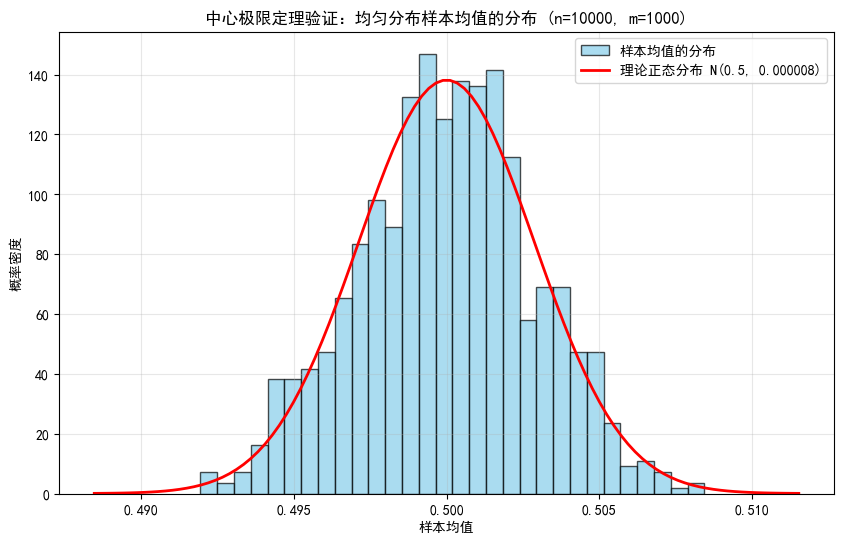

样本均值的实际方差: 0.00000828
理论方差 (σ²/n): 0.00000833
相对误差: 0.6924%


In [4]:
"""
3.2 编程题：中心极限定理模拟
1. 生成n=10000个服从均匀分布U(0,1)的随机变量，重复m=1000次，每次计算均值
2. 绘制1000个均值的直方图，并叠加理论正态分布的概率密度曲线
3. 计算这些均值的实际方差
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 设置参数
n = 10000      # 每个样本的随机变量个数
m = 1000       # 重复次数

# 1. 生成 m 个样本均值
np.random.seed(42)
sample_means = []

for _ in range(m):
    samples = np.random.uniform(0, 1, n)
    sample_means.append(np.mean(samples))

sample_means = np.array(sample_means)

# 2. 绘制直方图并叠加理论正态分布曲线
plt.figure(figsize=(10, 6))

# 绘制直方图
count, bins, _ = plt.hist(sample_means, bins=30, density=True, alpha=0.7, 
                           color='skyblue', edgecolor='black', label='样本均值的分布')

# 理论分布：N(μ, σ²/n)，其中 μ=0.5, σ²=1/12
theoretical_mean = 0.5
theoretical_var = (1/12) / n
theoretical_std = np.sqrt(theoretical_var)

x = np.linspace(theoretical_mean - 4*theoretical_std, 
                theoretical_mean + 4*theoretical_std, 100)
y = stats.norm.pdf(x, theoretical_mean, theoretical_std)
plt.plot(x, y, 'r-', linewidth=2, label=f'理论正态分布 N(0.5, {theoretical_var:.6f})')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理验证：均匀分布样本均值的分布 (n=10000, m=1000)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 计算这些均值的实际方差
actual_variance = np.var(sample_means)
theoretical_variance = (1/12) / n

print(f"样本均值的实际方差: {actual_variance:.8f}")
print(f"理论方差 (σ²/n): {theoretical_variance:.8f}")
print(f"相对误差: {abs(actual_variance - theoretical_variance) / theoretical_variance * 100:.4f}%")

第4.1题：偏导数计算
已知：
z = (w₁x₁ + w₂x₂ - y)²
其中 x₁=2, x₂=1, y=3 为常数

【第1问】偏导数表达式

令 u = w₁x₁ + w₂x₂ - y = 2w₁ + w₂ - 3
则 z = u²

∂z/∂w₁ = ∂z/∂u × ∂u/∂w₁ = 2u × x₁ = 2(2w₁ + w₂ - 3) × 2 = 4(2w₁ + w₂ - 3)

∂z/∂w₂ = ∂z/∂u × ∂u/∂w₂ = 2u × x₂ = 2(2w₁ + w₂ - 3) × 1 = 2(2w₁ + w₂ - 3)

答案：
∂z/∂w₁ = 4(2w₁ + w₂ - 3)
∂z/∂w₂ = 2(2w₁ + w₂ - 3)

【第2问】当 w₁=0.5, w₂=1 时的梯度值

计算 u = 2×0.5 + 1 - 3 = 1 + 1 - 3 = -1

∂z/∂w₁ = 4 × (-1) = -4
∂z/∂w₂ = 2 × (-1) = -2

答案：梯度 ∇z = [-4, -2]ᵀ

In [5]:
"""
4.2 编程题：手动实现反向传播
1. 定义前向计算：a = x·w₁, b = a + w₂, L = b²
2. 给定x=2, w1=1.5, w2=0.5，计算前向结果
3. 手动计算损失L对w1, w2的梯度，并验证与自动微分工具一致
"""

import torch

# 手动实现前向和反向传播
def manual_forward_backward(x, w1, w2):
    # 前向
    a = x * w1
    b = a + w2
    L = b ** 2
    
    # 反向传播（链式法则）
    dL_db = 2 * b
    db_da = 1
    da_dw1 = x
    db_dw2 = 1
    
    dL_dw1 = dL_db * db_da * da_dw1
    dL_dw2 = dL_db * db_dw2
    
    return L, dL_dw1, dL_dw2

# 给定参数
x = 2.0
w1 = 1.5
w2 = 0.5

# 手动计算
L_manual, grad_w1_manual, grad_w2_manual = manual_forward_backward(x, w1, w2)
print("===== 手动计算 =====")
print(f"前向结果 L = {L_manual}")
print(f"∂L/∂w1 = {grad_w1_manual}")
print(f"∂L/∂w2 = {grad_w2_manual}")

# 使用 PyTorch 自动微分验证
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

L_t.backward()

print("\n===== PyTorch自动微分 =====")
print(f"前向结果 L = {L_t.item()}")
print(f"∂L/∂w1 = {w1_t.grad.item()}")
print(f"∂L/∂w2 = {w2_t.grad.item()}")

# 验证一致性
print("\n===== 验证 =====")
print(f"∂L/∂w1 一致: {abs(grad_w1_manual - w1_t.grad.item()) < 1e-6}")
print(f"∂L/∂w2 一致: {abs(grad_w2_manual - w2_t.grad.item()) < 1e-6}")

===== 手动计算 =====
前向结果 L = 12.25
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

===== PyTorch自动微分 =====
前向结果 L = 12.25
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

===== 验证 =====
∂L/∂w1 一致: True
∂L/∂w2 一致: True


第5.1题：线性回归偏导数推导
已知：
线性回归模型：y = wx + b
均方误差损失：L = (1/n) Σ_{i=1}^n (y_i - (wx_i + b))²

【推导】∂L/∂w 和 ∂L/∂b

设残差 r_i = y_i - wx_i - b

∂L/∂w = (1/n) Σ 2(y_i - wx_i - b) × (-x_i)
      = -(2/n) Σ x_i(y_i - wx_i - b)

∂L/∂b = (1/n) Σ 2(y_i - wx_i - b) × (-1)
      = -(2/n) Σ (y_i - wx_i - b)

答案：
∂L/∂w = -(2/n) Σ_{i=1}^n x_i(y_i - wx_i - b)
∂L/∂b = -(2/n) Σ_{i=1}^n (y_i - wx_i - b)

Epoch 10/50, Loss: 0.1359
Epoch 20/50, Loss: 0.0909
Epoch 30/50, Loss: 0.0715
Epoch 40/50, Loss: 0.0601
Epoch 50/50, Loss: 0.0522


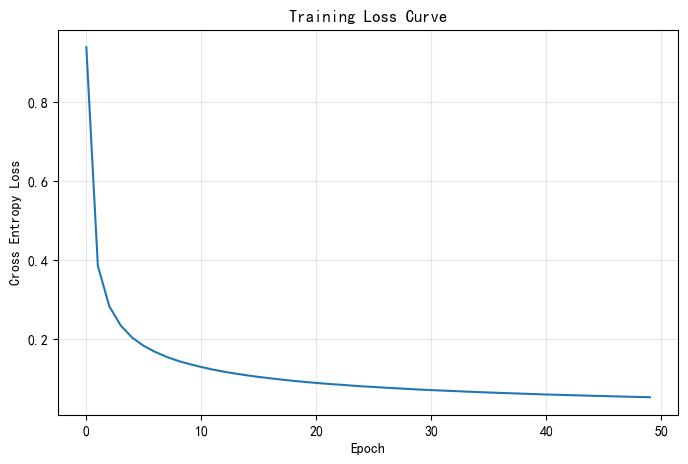


训练集准确率: 0.9923 (99.23%)
测试集准确率: 0.9667 (96.67%)


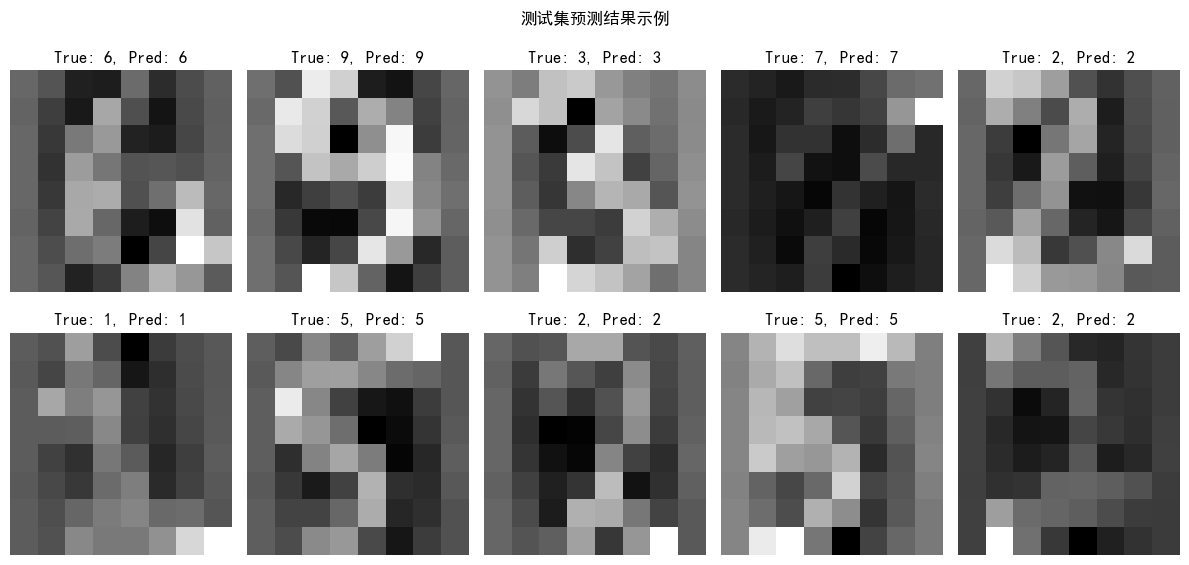

In [6]:
"""
5.2 编程题：从零实现Softmax回归对手写数字（MNIST）进行分类
1. 使用sklearn.datasets.load_digits()加载数据
2. 将图像展平为向量，对标签进行one-hot编码
3. 实现softmax函数、交叉熵损失函数
4. 使用小批量随机梯度下降（批量大小32，学习率0.1）训练50个epoch
5. 输出测试集上的准确率
"""

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# 1. 加载数据
digits = load_digits()
X = digits.data  # (1797, 64)
y = digits.target  # (1797,)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化（有助于收敛）
X_train = (X_train - np.mean(X_train, axis=0)) / (np.std(X_train, axis=0) + 1e-8)
X_test = (X_test - np.mean(X_test, axis=0)) / (np.std(X_test, axis=0) + 1e-8)

# 2. One-hot编码标签
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

num_classes = 10
num_features = X_train.shape[1]

# 3. 实现softmax函数和交叉熵损失
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))  # 数值稳定
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n = y_pred.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

# 初始化参数
np.random.seed(42)
W = np.random.randn(num_features, num_classes) * 0.01
b = np.zeros((1, num_classes))

# 4. 小批量随机梯度下降
batch_size = 32
learning_rate = 0.1
epochs = 50
n_samples = X_train.shape[0]

losses = []

for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    num_batches = 0
    
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        num_batches += 1
        
        # 反向传播
        grad_logits = y_pred - y_batch  # (batch_size, num_classes)
        grad_W = X_batch.T @ grad_logits / batch_size
        grad_b = np.sum(grad_logits, axis=0, keepdims=True) / batch_size
        
        # 更新参数
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b
    
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# 绘制损失曲线
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(alpha=0.3)
plt.show()

# 5. 测试准确率
def predict(X, W, b):
    logits = X @ W + b
    y_pred = softmax(logits)
    return np.argmax(y_pred, axis=1)

y_train_pred = predict(X_train, W, b)
y_test_pred = predict(X_test, W, b)

train_accuracy = np.mean(y_train_pred == y_train)
test_accuracy = np.mean(y_test_pred == y_test)

print(f"\n训练集准确率: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# 显示一些预测结果
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'True: {y_test[i]}, Pred: {y_test_pred[i]}')
    ax.axis('off')
plt.suptitle('测试集预测结果示例')
plt.tight_layout()
plt.show()

第6.1题：最大似然估计
已知：
样本 x₁, x₂, ..., x_n 独立同分布于正态分布 N(μ, σ²)

【第1问】似然函数

L(μ, σ²) = ∏_{i=1}^n (1/√(2πσ²)) × exp(-(x_i - μ)²/(2σ²))

对数似然：
ℓ(μ, σ²) = -n/2 × ln(2π) - n/2 × ln(σ²) - 1/(2σ²) × Σ(x_i - μ)²

【第2问】证明 μ 的 MLE

∂ℓ/∂μ = (1/σ²) Σ(x_i - μ) = 0
⇒ Σ(x_i - μ) = 0
⇒ Σx_i - nμ = 0
⇒ μ̂ = (1/n) Σ x_i

证毕。

【第3问】证明 σ² 的 MLE

令 θ = σ²，∂ℓ/∂θ = -n/(2θ) + 1/(2θ²) Σ(x_i - μ)² = 0
⇒ -nθ + Σ(x_i - μ)² = 0
⇒ θ̂ = (1/n) Σ(x_i - μ)²

代入 μ̂：
σ̂² = (1/n) Σ(x_i - μ̂)²

证毕。

训练集大小: (300, 2)
测试集大小: (100, 2)
开始训练...
Iteration 200/1000, Loss: 0.414925
Iteration 400/1000, Loss: 0.409431
Iteration 600/1000, Loss: 0.406773
Iteration 800/1000, Loss: 0.405360
Iteration 1000/1000, Loss: 0.404582


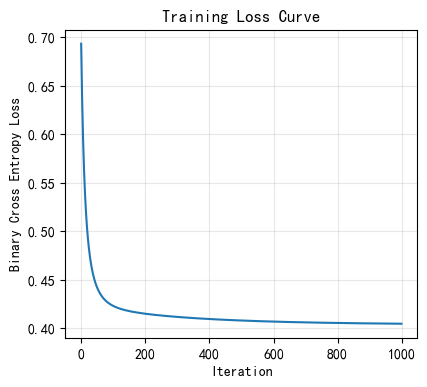

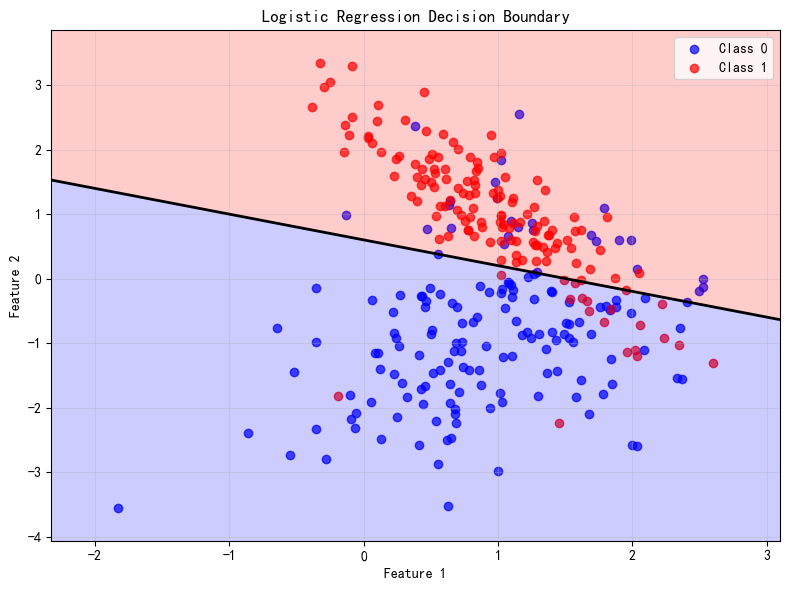


训练集准确率: 0.8467 (84.67%)
测试集准确率: 0.9000 (90.00%)

学习到的参数:
w = [0.6652, 1.6682]
b = -1.0032


In [7]:
"""
6.2 编程题：实现二分类逻辑回归模型
1. 生成两类线性可分的数据：每类200个样本，特征维度为2
2. 定义sigmoid函数和二元交叉熵损失
3. 使用梯度下降法（学习率0.1，迭代1000次）学习参数w, b
4. 绘制决策边界，并计算模型在测试集上的分类准确率
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 1. 生成两类线性可分数据
np.random.seed(42)
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, 
                           n_informative=2, n_clusters_per_class=1, 
                           n_classes=2, flip_y=0.05, random_state=42)

# 将标签转换为 0/1
y = y.reshape(-1, 1)

# 划分训练集和测试集
train_size = 300
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

# 2. 定义sigmoid函数和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # 防止溢出

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    loss = -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
    return loss

# 3. 梯度下降法
def logistic_regression_gd(X, y, learning_rate=0.1, n_iterations=1000, verbose=True):
    n_samples, n_features = X.shape
    
    # 初始化参数
    w = np.zeros((n_features, 1))
    b = 0.0
    
    losses = []
    
    for i in range(n_iterations):
        # 前向传播
        z = X @ w + b
        y_pred = sigmoid(z)
        
        # 计算损失
        loss = binary_cross_entropy(y_pred, y)
        losses.append(loss)
        
        # 反向传播
        dw = (1/n_samples) * (X.T @ (y_pred - y))
        db = (1/n_samples) * np.sum(y_pred - y)
        
        # 更新参数
        w -= learning_rate * dw
        b -= learning_rate * db
        
        if verbose and (i+1) % 200 == 0:
            print(f"Iteration {i+1}/{n_iterations}, Loss: {loss:.6f}")
    
    return w, b, losses

# 训练模型
print("开始训练...")
w, b, losses = logistic_regression_gd(X_train, y_train, learning_rate=0.1, 
                                        n_iterations=1000, verbose=True)

# 绘制损失曲线
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Binary Cross Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(alpha=0.3)

# 4. 绘制决策边界
def plot_decision_boundary(X, y, w, b):
    plt.figure(figsize=(8, 6))
    
    # 绘制数据点
    plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], 
                c='blue', label='Class 0', alpha=0.7)
    plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], 
                c='red', label='Class 1', alpha=0.7)
    
    # 绘制决策边界
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ w + b)
    Z = Z.reshape(xx.shape)
    
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Logistic Regression Decision Boundary')
    plt.legend()
    plt.grid(alpha=0.3)
    return plt

plot_decision_boundary(X_train, y_train, w, b)
plt.tight_layout()
plt.show()

# 5. 计算测试集准确率
def predict(X, w, b, threshold=0.5):
    z = X @ w + b
    y_pred_prob = sigmoid(z)
    return (y_pred_prob >= threshold).astype(int)

y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)

train_accuracy = np.mean(y_train_pred == y_train)
test_accuracy = np.mean(y_test_pred == y_test)

print(f"\n训练集准确率: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# 输出学习到的参数
print(f"\n学习到的参数:")
print(f"w = [{w[0,0]:.4f}, {w[1,0]:.4f}]")
print(f"b = {b:.4f}")